In [22]:
import pandas as pd

df = pd.read_csv("teina010_linear.csv", sep=",", encoding="utf-8")
df

,DATAFLOW,LAST UPDATE,freq,na_item,s_adj,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG
0,ESTAT:TEINA010(1.0),24/10/24 23:00:00,Q,B1GQ,SCA,MIO_EUR_SCA,AT,2021-Q3,105003.0,NaN
1,ESTAT:TEINA010(1.0),24/10/24 23:00:00,Q,B1GQ,SCA,MIO_EUR_SCA,AT,2021-Q4,105145.6,NaN
2,ESTAT:TEINA010(1.0),24/10/24 23:00:00,Q,B1GQ,SCA,MIO_EUR_SCA,AT,2022-Q1,107582.7,NaN
3,ESTAT:TEINA010(1.0),24/10/24 23:00:00,Q,B1GQ,SCA,MIO_EUR_SCA,AT,2022-Q2,111270.0,NaN
4,ESTAT:TEINA010(1.0),24/10/24 23:00:00,Q,B1GQ,SCA,MIO_EUR_SCA,AT,2022-Q3,113568.9,NaN
...,...,...,...,...,...,...,...,...,...,...
439,ESTAT:TEINA010(1.0),24/10/24 23:00:00,Q,B1GQ,SCA,MIO_EUR_SCA,TR,2023-Q2,253839.3,NaN
440,ESTAT:TEINA010(1.0),24/10/24 23:00:00,Q,B1GQ,SCA,MIO_EUR_SCA,TR,2023-Q3,253961.9,NaN
441,ESTAT:TEINA010(1.0),24/10/24 23:00:00,Q,B1GQ,SCA,MIO_EUR_SCA,TR,2023-Q4,267134.4,NaN
442,ESTAT:TEINA010(1.0),24/10/24 23:00:00,Q,B1GQ,SCA,MIO_EUR_SCA,TR,2024-Q1,284283.5,NaN


In [26]:
import requests

url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"
dataset_kode = "teina010"

request_url = f"{url}/{dataset_kode}"
params = {"format": "JSON", "lang": "EN"}

response = requests.get(request_url, params=params)

minium 19135.2


array([ True, False,  True,  True, False,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True, False,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True, False, False])

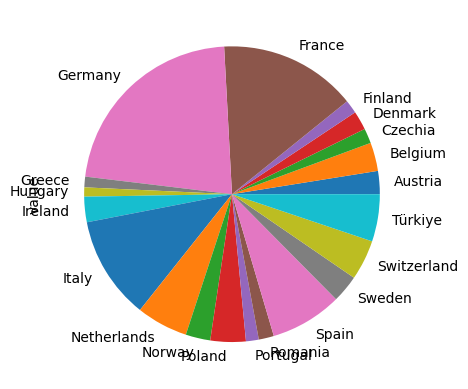

In [153]:
from pyjstat import pyjstat
import matplotlib.pyplot as plt

dataset = pyjstat.Dataset.read(response.text)
df = dataset.write('dataframe')
df_id = dataset.write('dataframe', naming='id')
df = df.drop(["Time frequency",
             "National accounts indicator (ESA 2010)",
             "Seasonal adjustment", "Unit of measure"], axis=1)
df["Time"] = df["Time"].map(lambda x: pd.Period(x.replace("-", ""), freq='Q'))
df = df.set_index(["Geopolitical entity (reporting)", "Time"])
df.sort_index(level=[0,1])
df_total = df.groupby(by="Geopolitical entity (reporting)").sum()
df_total = df_total.reset_index()
df_total = df_total[~df_total["Geopolitical entity (reporting)"].str.contains("Euro")]
df_total = df_total.set_index("Geopolitical entity (reporting)")
minimum = df_total.drop("United Kingdom")["value"].min()
df_total[df_total["value"] > 20*minimum].plot.pie(subplots=True, legend=False)
print("minium", minimum)
df_total.index.str.contains("a")

In [156]:
from pyjstat import pyjstat
import matplotlib.pyplot as plt

dataset = pyjstat.Dataset.read(response.text)
df = dataset.write('dataframe')
df_id = dataset.write('dataframe', naming='id')
df = df.drop(["Time frequency",
             "National accounts indicator (ESA 2010)",
             "Seasonal adjustment", "Unit of measure"], axis=1)
df["Time"] = df["Time"].map(lambda x: pd.Period(x.replace("-", ""), freq='Q'))
df.to_csv("eu_GDP.csv", index=False)